In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import ipywidgets as widgets
from IPython.display import display

# ──────────────────────────────────────────────
# Konfiguration
# ──────────────────────────────────────────────
MAX_CH        = 10
CSV_PATH      = 'data/Konvektionsfrage/260304-171942.CSV'
LABELS_PATH   = 'data/new_channel_labels - Luft.xlsx'
UTOT_PATH     = 'data/UtoT.xlsx'
sheet_name   = 'ECK2'
#sheet_name    = 'ECH2'

# Kanal-Konfiguration
NTC_CHANNEL    = 'CH9'
DIODE_CHANNEL  = 'CH10'

# NTC-Parameter (NTC_CHANNEL)
V_SUPPLY      = 3.3
R_FIX         = 20_000
R0            = 47_000
B_CONST       = 4050
T0_K          = 298.15

# DIODE_CHANNEL Regressionsmethode:
#   'linear'  → Polynom Grad 1  (schnell, einfach)
#   'poly2'   → Polynom Grad 2  (leichte Krümmung)
#   'poly3'   → Polynom Grad 3  (stärkere Krümmung)
#   'spline'  → Kubischer Spline (folgt Tabelle exakt, kein Extrapolieren)
CH11_REGRESSION = 'linear'

# UtoT Filterung:
#   'MW'  → Mittelwert aller Messungen
#   'L'   → nur Position Low
#   'H'   → nur Position High
#   'L_U' → Position Low, Phase U
#   'L_V' → Position Low, Phase V
#   'L_W' → Position Low, Phase W
#   'H_U' → Position High, Phase U
#   'H_V' → Position High, Phase V
#   'H_W' → Position High, Phase W
UTOT_FILTER = 'L_W'

# Channels ausblenden — Liste mit Channel-Namen, z.B. ['CH3', 'CH5']
# Leer lassen um alle anzuzeigen: []
HIDE_CHANNELS = ['CH7']


# ──────────────────────────────────────────────
# Hilfsfunktionen
# ──────────────────────────────────────────────
def ntc_voltage_to_celsius(v_ntc, v_supply=V_SUPPLY, r_fix=R_FIX,
                            r0=R0, b=B_CONST, t0_k=T0_K):
    """Spannung über NTC (Spannungsteiler) → Temperatur in °C."""
    r_ntc    = (v_ntc * r_fix) / (v_supply - v_ntc)
    t_kelvin = 1.0 / (1.0 / t0_k + np.log(r_ntc / r0) / b)
    return t_kelvin - 273.15


def load_utot(path, utot_filter=UTOT_FILTER, verbose=False):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=0)
    col_map = {c: c.strip().lower() for c in raw.columns}
    raw.rename(columns=col_map, inplace=True)

    # Spalten finden
    temp_col  = next((c for c in raw.columns
                      if 'temp' in c or '°c' in c or 'temperatur' in c), None)
    volt_col  = next((c for c in raw.columns
                      if 'span' in c or ' mv' in c or 'mv' in c
                      or (c.startswith('u') and 'spannung' not in c)), None)
    pos_col   = next((c for c in raw.columns if 'pos' in c), None)
    phase_col = next((c for c in raw.columns if 'phase' in c), None)

    if temp_col is None or volt_col is None:
        print(f'⚠️  Gefundene Spalten: {list(raw.columns)}')
        raise ValueError('Temperatur- oder Spannungsspalte nicht erkannt.')

    df = raw[[temp_col, volt_col, pos_col, phase_col]].copy()
    df.columns = ['temperature_c', 'voltage_mv', 'position', 'phase']

    # Temperatur ffill
    df['temperature_c'] = pd.to_numeric(
        df['temperature_c'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df['temperature_c'] = df['temperature_c'].ffill()

    # Position und Phase ffill
    df['position'] = df['position'].astype(str).str.strip().str.upper().replace('NAN', pd.NA)
    df['position'] = df['position'].ffill()
    df['phase'] = df['phase'].astype(str).str.strip().str.upper().replace('NAN', pd.NA)
    df['phase'] = df['phase'].ffill()

    # Spannung bereinigen und mV → V
    df['voltage_mv'] = pd.to_numeric(
        df['voltage_mv'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df['voltage_v'] = df['voltage_mv'] / 1000.0
    df.dropna(subset=['temperature_c', 'voltage_v'], inplace=True)

    # ── Filter anwenden ──────────────────────────────────────
    if utot_filter == 'MW':
        pass
    elif utot_filter in ('L', 'H'):
        df = df[df['position'] == utot_filter]
    elif '_' in utot_filter:
        pos, phase = utot_filter.split('_')
        df = df[(df['position'] == pos) & (df['phase'] == phase)]
    else:
        raise ValueError(f'Unbekannter UTOT_FILTER: {utot_filter!r}. '
                         f'Gültig: MW, L, H, L_U, L_V, L_W, H_U, H_V, H_W')


    # Mittelwert pro Temperatur
    df_mean = (df.groupby('temperature_c')['voltage_v']
                 .mean()
                 .reset_index()
                 .sort_values('voltage_v'))

    if verbose:
        print(f'UtoT [{utot_filter}] — {len(df_mean)} Temperaturpunkte:')
        print(df_mean.to_string(index=False))
    return df_mean


def build_ch11_converter(path, method=CH11_REGRESSION, utot_filter=UTOT_FILTER, verbose=False):
    """
    Liest UtoT.xlsx und erstellt Konvertierungsfunktion U (Volt) → T (°C).

    Methoden:
      'linear' : Polynom Grad 1  – gut wenn U/T-Beziehung annähernd gerade ist
      'poly2'  : Polynom Grad 2  – leichte Krümmung
      'poly3'  : Polynom Grad 3  – stärkere Krümmung
      'spline' : Kubischer Spline – folgt Tabellenpunkten exakt,
                                    kein Extrapolieren außerhalb des Bereichs
    """
    lut = load_utot(path, utot_filter=utot_filter, verbose=verbose)
    u   = lut['voltage_v'].values
    t   = lut['temperature_c'].values

    if method in ('linear', 'poly2', 'poly3'):
        degree = {'linear': 1, 'poly2': 2, 'poly3': 3}[method]
        coeffs = np.polyfit(u, t, degree)
        poly   = np.poly1d(coeffs)
        t_pred = poly(u)
        r2 = 1 - np.sum((t - t_pred)**2) / np.sum((t - np.mean(t))**2)
        if verbose:
            print(f'{DIODE_CHANNEL} Regression [{method}] — R² = {r2:.6f}')
        return poly

    elif method == 'spline':
        if len(u) < 4:
            print(f'⚠️  Zu wenig Punkte für kubischen Spline ({len(u)}), fallback auf linear.')
            return build_ch11_converter(path, method='linear', verbose=verbose)
        spline = interp1d(u, t, kind='cubic', bounds_error=False, fill_value=np.nan)
        if verbose:
            print(f'{DIODE_CHANNEL} Spline — {len(u)} Stützpunkte, Bereich: {u.min():.4f}–{u.max():.4f} V')
        return spline

    else:
        raise ValueError(f'Unbekannte Methode: {method!r}. '
                         f'Gültig: linear, poly2, poly3, spline')


def plot_ch11_regression(path, method=CH11_REGRESSION, utot_filter=UTOT_FILTER, verbose=False):
    """Zeigt Regressionskurve vs. Kalibrierpunkte zur visuellen Prüfung."""
    lut       = load_utot(path, utot_filter=utot_filter, verbose=verbose)
    u         = lut['voltage_v'].values
    t         = lut['temperature_c'].values
    converter = build_ch11_converter(path, method, utot_filter=utot_filter)
    u_fine    = np.linspace(u.min(), u.max(), 500)

    plt.figure(figsize=(8, 4))
    plt.scatter(u, t, label='Kalibrierpunkte (Mittelwert)', zorder=5,
                color='steelblue', s=80)
    plt.plot(u_fine, converter(u_fine), label=f'Regression [{method}]',
             color='tomato', linewidth=2)
    plt.xlabel('Spannung (V)')
    plt.ylabel('Temperatur (°C)')
    plt.title(f'{DIODE_CHANNEL} — U→T Kalibrierung [{method}]')
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_labels(path):
    """Liest channel_labels.xlsx → Dict {channel: label}."""
    try:
        ldf = pd.read_excel(path, sheet_name=sheet_name)
        ldf.columns = ldf.columns.str.strip().str.lower()
        return dict(zip(ldf['channel'].str.strip(), ldf['label'].str.strip()))
    except FileNotFoundError:
        print(f'⚠️  Label-Datei nicht gefunden: {path} — Kanalnamen werden verwendet.')
        return {}


def read_and_clean(path, ch11_converter=None, max_ch=MAX_CH, skiprows=33):
    """CSV einlesen, säubern, NTC_CHANNEL (NTC) und DIODE_CHANNEL (Kalibrierung) umrechnen."""
    ch_cols = [f'CH{i}' for i in range(1, max_ch + 1)]
    names   = ['index', 'datetime', 'interval'] + ch_cols + \
              ['Alarm1_10', 'Alarm11_20', 'AlarmOut']

    df = pd.read_csv(path, skiprows=skiprows, header=None, names=names,
                     sep=',', engine='python', skipinitialspace=True, dtype=str)

    # Komplett leere Spalten entfernen
    if df.shape[1] > len(names):
        df = df.loc[:, ~df.apply(
            lambda col: col.astype(str).str.strip().replace('', pd.NA).isna().all()
        )]

    # Index als Zahl parsen
    df['index'] = pd.to_numeric(df['index'], errors='coerce')

    # CH-Spalten bereinigen
    for c in ch_cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                         .str.replace(r'[+\s]', '', regex=True)
                         .str.replace(',', '.', regex=False))
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # NTC_CHANNEL: NTC Spannungsteiler → °C
    if NTC_CHANNEL in df.columns:
        raw = df[NTC_CHANNEL].copy().where(lambda x: (x > 0) & (x < V_SUPPLY))
        df[NTC_CHANNEL] = ntc_voltage_to_celsius(raw)

    # DIODE_CHANNEL: Kalibrierungstabelle → °C
    if DIODE_CHANNEL in df.columns and ch11_converter is not None:
        df[DIODE_CHANNEL] = ch11_converter(df[DIODE_CHANNEL].values)

    return df, ch_cols


def plot_channels_interactive(df, ch_cols, labels=None):
    if labels is None:
        labels = {}

    valid_cols = [ch for ch in ch_cols
                  if ch in df.columns
                  and df[ch].notna().any()
                  and ch not in HIDE_CHANNELS]

    all_times = df['index'].dropna().sort_values().unique()
    t_min = all_times[0]
    t_max = all_times[-1]

    fig, ax = plt.subplots(figsize=(16, 9))
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.07, right=0.97)

    # ── Widgets ───────────────────────────────────────────────
    slider = widgets.SelectionRangeSlider(
        options     = [(str(int(t)), t) for t in all_times],
        index       = (0, len(all_times) - 1),
        description = 'Zeitbereich',
        layout      = widgets.Layout(width='95%'),
        style       = {'description_width': '100px'}
    )
    idx_min_box = widgets.IntText(
        value       = int(all_times[0]),
        description = 'Von:',
        layout      = widgets.Layout(width='150px'),
        style       = {'description_width': '35px'}
    )
    idx_max_box = widgets.IntText(
        value       = int(all_times[-1]),
        description = 'Bis:',
        layout      = widgets.Layout(width='150px'),
        style       = {'description_width': '35px'}
    )
    manual_scale = widgets.Checkbox(
        value       = False,
        description = 'Manuelle Y-Achse',
        indent      = False,
        layout      = widgets.Layout(width='180px')
    )
    y_min_box = widgets.FloatText(
        value       = 0.0,
        description = 'Y min:',
        disabled    = True,
        layout      = widgets.Layout(width='160px'),
        style       = {'description_width': '45px'}
    )
    y_max_box = widgets.FloatText(
        value       = 100.0,
        description = 'Y max:',
        disabled    = True,
        layout      = widgets.Layout(width='160px'),
        style       = {'description_width': '45px'}
    )
    btn_filter_cold = widgets.ToggleButton(
        value=False, description='< 20°C ausblenden',
        button_style='', layout=widgets.Layout(width='160px')
    )
    btn_kelvin = widgets.ToggleButton(
        value=False, description='Kelvin anzeigen',
        button_style='', layout=widgets.Layout(width='130px')
    )
    btn_peak_zoom = widgets.ToggleButton(
        value=False, description='Peak Diode zoom',
        button_style='warning', layout=widgets.Layout(width='150px')
    )

    # ── Helpers ───────────────────────────────────────────────
    def update(x_range):
        t_start, t_end = x_range
        ax.clear()

        mask    = (df['index'] >= t_start) & (df['index'] <= t_end)
        df_zoom = df[mask].copy()

        if btn_peak_zoom.value:
            diode_ch = valid_cols[-1]
            peak_idx = df.loc[df[diode_ch] >= 20, diode_ch].idxmax()
            peak_x   = df.loc[peak_idx, 'index']
            all_idx  = df['index'].values
            pos      = np.searchsorted(all_idx, peak_x)
            x_before = all_idx[max(0, pos - 1)]
            x_after  = all_idx[min(len(all_idx) - 1, pos + 1)]
            mask     = (df['index'] >= x_before) & (df['index'] <= x_after)
            df_zoom  = df[mask].copy()

        for ch in valid_cols:
            series = df_zoom[ch].copy()
            if btn_filter_cold.value or btn_peak_zoom.value:
                series = series.where(series >= 20)
            if btn_kelvin.value:
                series = series + 273.15
            ax.plot(df_zoom['index'], series, label=labels.get(ch, ch), marker='')

        ax.set_xlabel('Messpunkt')
        ax.set_ylabel('Temperatur in K' if btn_kelvin.value else 'Temperatur in °C')
        ax.set_title('Temperaturverlauf der Messkanäle')
        handles, legend_labels = ax.get_legend_handles_labels()
        by_label = dict(zip(legend_labels, handles))
        ax.legend(by_label.values(), by_label.keys(), ncol=2, fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.relim()
        ax.autoscale_view()
        if manual_scale.value:
            ax.set_ylim(y_min_box.value, y_max_box.value)
        fig.canvas.draw_idle()

    def on_manual_scale_change(change):
        is_manual = change['new']
        y_min_box.disabled = not is_manual
        y_max_box.disabled = not is_manual
        if is_manual:
            current_ylim = ax.get_ylim()
            y_min_box.value = round(current_ylim[0], 2)
            y_max_box.value = round(current_ylim[1], 2)
        update(slider.value)

    def on_slider_change(change):
        t_start, t_end = change['new']
        idx_min_box.value = int(t_start)
        idx_max_box.value = int(t_end)
        update(change['new'])

    def on_ylim_change(change):
        if manual_scale.value:
            update(slider.value)

    def on_idx_box_change(change):
        lo   = min(all_times, key=lambda x: abs(x - idx_min_box.value))
        hi   = min(all_times, key=lambda x: abs(x - idx_max_box.value))
        lo_i = list(all_times).index(lo)
        hi_i = list(all_times).index(hi)
        slider.index = (lo_i, hi_i)

    # ── Observe ───────────────────────────────────────────────
    slider.observe(on_slider_change,           names='value')
    idx_min_box.observe(on_idx_box_change,     names='value')
    idx_max_box.observe(on_idx_box_change,     names='value')
    manual_scale.observe(on_manual_scale_change, names='value')
    y_min_box.observe(on_ylim_change,          names='value')
    y_max_box.observe(on_ylim_change,          names='value')
    btn_filter_cold.observe(lambda c: update(slider.value), names='value')
    btn_kelvin.observe(lambda c: update(slider.value),      names='value')
    btn_peak_zoom.observe(lambda c: update(slider.value),   names='value')

    # ── Layout ────────────────────────────────────────────────
    slider_row     = widgets.HBox([slider, idx_min_box, idx_max_box])
    scale_controls = widgets.HBox(
        [manual_scale, y_min_box, y_max_box, btn_filter_cold, btn_kelvin, btn_peak_zoom],
        layout=widgets.Layout(align_items='center', margin='4px 0')
    )

    update((t_min, t_max))
    display(widgets.VBox([slider_row, scale_controls]))

UtoT [L_W] — 8 Temperaturpunkte:
 temperature_c  voltage_v
         125.0     0.2613
         105.0     0.3025
          80.0     0.3649
          60.0     0.4130
          40.0     0.4600
          22.0     0.5039
           0.0     0.5556
         -20.0     0.5950


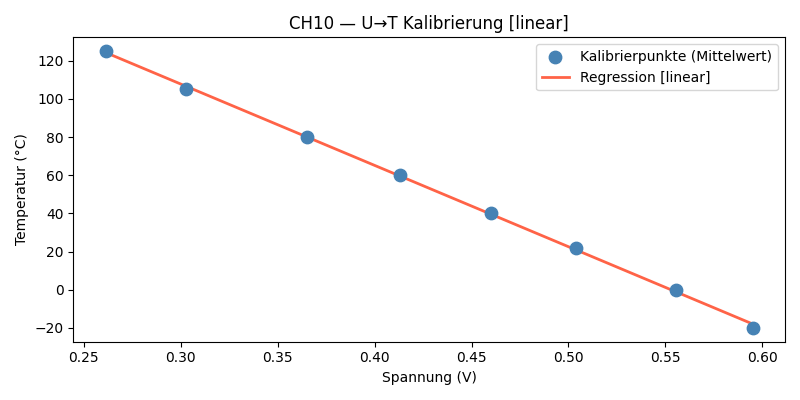

CSV: 6118 Zeilen gelesen


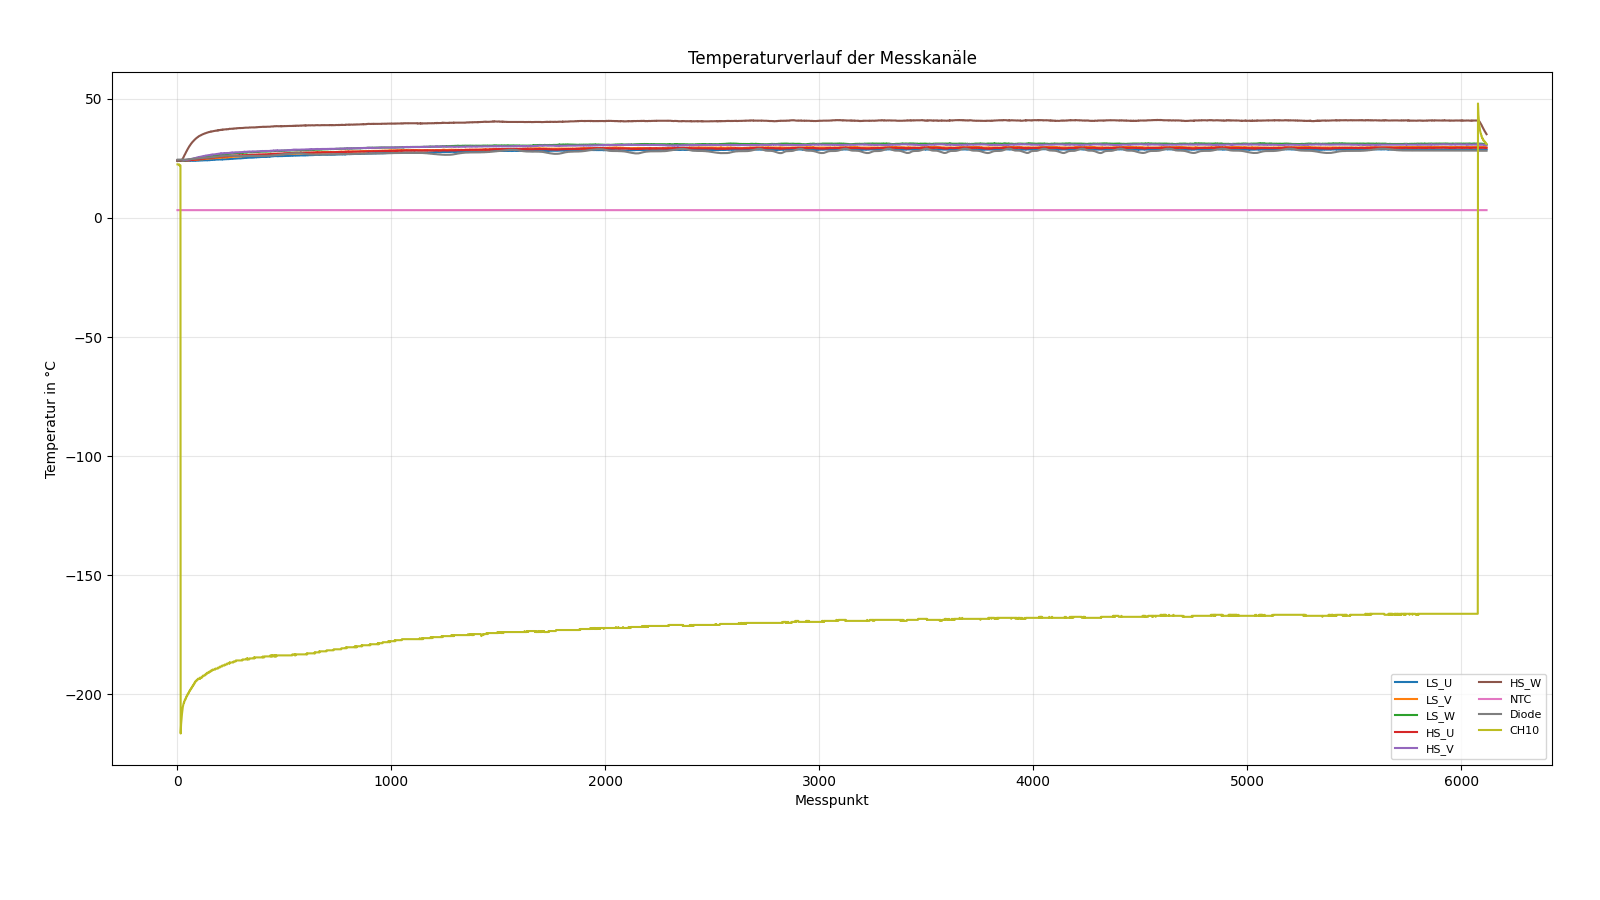

In [6]:
%matplotlib widget

# 1) Regression prüfen — CH11_REGRESSION oben ändern und neu ausführen
plot_ch11_regression(UTOT_PATH, method=CH11_REGRESSION, utot_filter=UTOT_FILTER, verbose=True)

# 2) Labels laden
labels = load_labels(LABELS_PATH)

# 3) Konverter bauen und CSV laden
ch11_conv   = build_ch11_converter(UTOT_PATH, method=CH11_REGRESSION, utot_filter=UTOT_FILTER)
df, ch_cols = read_and_clean(CSV_PATH, ch11_converter=ch11_conv, max_ch=MAX_CH)

print(f'CSV: {len(df)} Zeilen gelesen')

# 4) Plot (interaktiv)
plot_channels_interactive(df, ch_cols, labels=labels)
